# 阶段 2.2：气动参数计算与分析

本 Notebook 完成：

1. 周向 N=72 采样的数值 Cp 计算

2. 理论 Cp=1-4sin^2(theta) 对比与 RMSE 评估

3. 极坐标压力分布图与关键点标注

4. CSV 数据导出与 Markdown 报告生成


## Cp 公式与理论对比说明

压力系数定义为

$$
C_p = 1 - \left(\frac{V}{U}\right)^2
$$

对于无环量圆柱势流，圆柱表面切向速度满足 $V_\theta = -2U\sin\theta$，因此理论分布为

$$
C_p = 1 - 4\sin^2\theta
$$

后续代码将给出数值 $C_p$、理论 $C_p$、RMSE，以及极坐标图与 CSV 导出。

In [ ]:
import platform

import matplotlib

import numpy

import pandas

import sympy



print('Python :', platform.python_version())

print('numpy  :', numpy.__version__)

print('pandas :', pandas.__version__)

print('sympy  :', sympy.__version__)

print('matplotlib:', matplotlib.__version__)


In [ ]:
from pathlib import Path

import sys


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise RuntimeError(
        "Cannot locate project root. Please open a folder inside flow_simulation_project."
    )


ROOT = find_project_root()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root detected.")

Project root detected.


RMSE = 0.000000
RMSE < 0.01 ? True


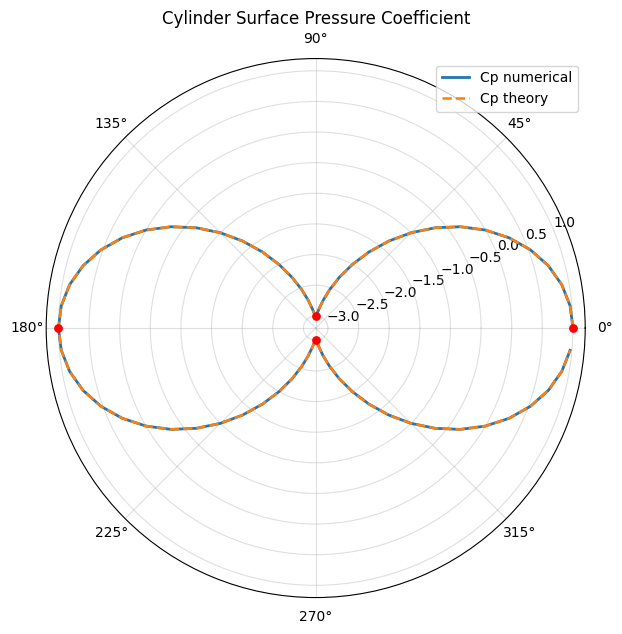

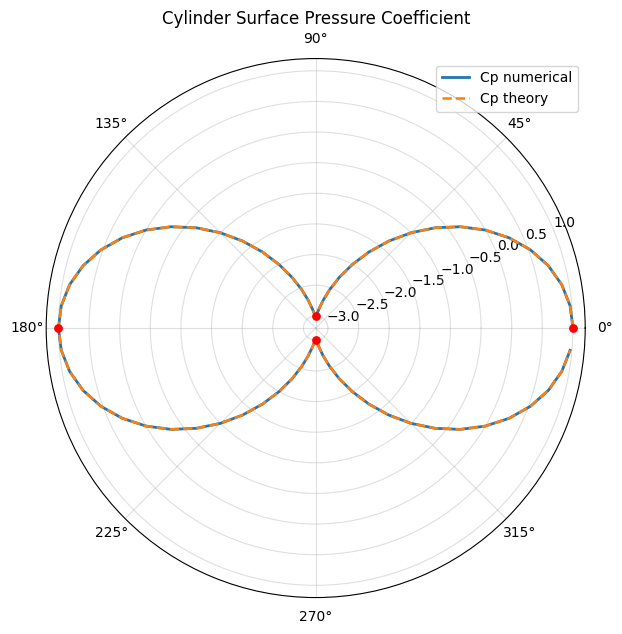

In [2]:
from src.core.pressure import cylinder_surface_cp, rmse, export_surface_cp_csv, write_pressure_report

from src.visualization.plot_pressure import plot_cp_polar



U = 3.0

a = 1.2

Gamma = 0.0

N = 72



surf = cylinder_surface_cp(U=U, a=a, gamma=Gamma, n_points=N)

rmse_value = rmse(surf['cp_num'], surf['cp_theo'])

print(f"RMSE = {rmse_value:.6f}")

print("RMSE < 0.01 ?", rmse_value < 0.01)



fig, ax = plot_cp_polar(surf['theta'], surf['cp_num'], surf['cp_theo'])

fig


In [3]:
csv_path = ROOT / 'data' / 'results.csv'

fig_path = ROOT / 'reports' / 'figures' / 'stage2_pressure_polar.png'

report_path = ROOT / 'reports' / 'report_stage2_pressure.md'



fig.savefig(fig_path, dpi=220, bbox_inches='tight')

df = export_surface_cp_csv(csv_path, surf)

write_pressure_report(

    report_path=report_path,

    figure_path=Path('figures/stage2_pressure_polar.png'),

    surface_data=surf,

    rmse_value=rmse_value,

    U=U,

    a=a,

    gamma=Gamma,

)



df.head()


,theta_deg,cp_num,cp_theo,error,u,v,v_mag
0,0.0,1.000000,1.000000,0.000000e+00,3.330669e-16,-0.000000,3.330669e-16
1,5.0,0.969616,0.969616,0.000000e+00,4.557674e-02,-0.520945,5.229345e-01
2,10.0,0.879385,0.879385,0.000000e+00,1.809221e-01,-1.026060,1.041889e+00
3,15.0,0.732051,0.732051,0.000000e+00,4.019238e-01,-1.500000,1.552914e+00
4,20.0,0.532089,0.532089,1.110223e-16,7.018667e-01,-1.928363,2.052121e+00


## 阶段 3.1：气动力悖论分析与环量修正

- 先积分验证 Gamma=0 时阻力和升力近零。

- 再扫描 Gamma，观察 Cl 与 Cd 的变化规律并输出报告。


In [6]:
import numpy as np

import importlib

import src.core.pressure as pressure_mod



pressure_mod = importlib.reload(pressure_mod)

aerodynamic_force_from_surface_cp = pressure_mod.aerodynamic_force_from_surface_cp

circulation_force_study = pressure_mod.circulation_force_study



rho = 1.225



# 1) Gamma=0：验证理想模型升阻力近零

force0 = aerodynamic_force_from_surface_cp(surf['theta'], surf['cp_num'], U=U, a=a, rho=rho)

print('Gamma=0 force:', force0)



# 2) Gamma 扫描：观察环量对气动力影响

gamma_values = np.linspace(-10.0, 10.0, 21)

force_df = circulation_force_study(U=U, a=a, gamma_values=gamma_values, n_points=720, rho=rho)

force_df.head()


Gamma=0 force: {'Fx_per_span': -4.590078317434632e-17, 'Fy_per_span': -1.6897225806056238e-15, 'Cd': -3.469446951953614e-18, 'Cl': -1.2771901591879242e-16}


,gamma,Fx_per_span,Fy_per_span,Cd,Cl
0,-10.0,-1.468825e-15,36.750,-1.110223e-16,2.777778
1,-9.0,-0.000000e+00,33.075,-0.000000e+00,2.500000
2,-8.0,3.672063e-16,29.400,2.775558e-17,2.222222
3,-7.0,2.203238e-15,25.725,1.665335e-16,1.944444
4,-6.0,-0.000000e+00,22.050,-0.000000e+00,1.666667


saved: reports/figures/stage3_gamma_force.png
saved: data/stage3_force_scan.csv
saved: reports/report_stage3_paradox.md


,gamma,Fx_per_span,Fy_per_span,Cd,Cl
16,6.0,2.203238e-15,-22.050,1.665335e-16,-1.666667
17,7.0,1.101619e-15,-25.725,8.326673e-17,-1.944444
18,8.0,3.672063e-16,-29.400,2.775558e-17,-2.222222
19,9.0,3.672063e-16,-33.075,2.775558e-17,-2.500000
20,10.0,-3.672063e-16,-36.750,-2.775558e-17,-2.777778


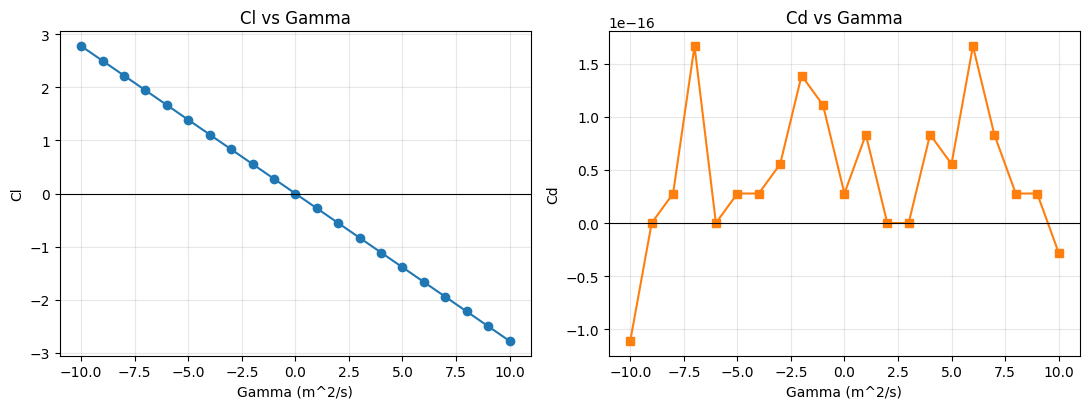

In [ ]:
import matplotlib.pyplot as plt


write_stage3_report = pressure_mod.write_stage3_report


fig2, ax2 = plt.subplots(1, 2, figsize=(11, 4.2))

ax2[0].plot(force_df['gamma'], force_df['Cl'], marker='o', color='tab:blue')

ax2[0].axhline(0.0, color='black', linewidth=0.8)

ax2[0].set_xlabel('Gamma (m^2/s)')

ax2[0].set_ylabel('Cl')

ax2[0].set_title('Cl vs Gamma')

ax2[0].grid(alpha=0.3)


ax2[1].plot(force_df['gamma'], force_df['Cd'], marker='s', color='tab:orange')

ax2[1].axhline(0.0, color='black', linewidth=0.8)

ax2[1].set_xlabel('Gamma (m^2/s)')

ax2[1].set_ylabel('Cd')

ax2[1].set_title('Cd vs Gamma')

ax2[1].grid(alpha=0.3)


fig2.tight_layout()


stage3_fig = ROOT / 'reports' / 'figures' / 'stage3_gamma_force.png'

stage3_csv = ROOT / 'data' / 'stage3_force_scan.csv'

stage3_report = ROOT / 'reports' / 'report_stage3_paradox.md'


fig2.savefig(stage3_fig, dpi=220, bbox_inches='tight')

force_df.to_csv(stage3_csv, index=False)

write_stage3_report(
    report_path=stage3_report,
    force_df=force_df,
    figure_path=Path('figures/stage3_gamma_force.png'),
    U=U,
    a=a,
    rho=rho,
)


print('saved:', stage3_fig.relative_to(ROOT))
print('saved:', stage3_csv.relative_to(ROOT))
print('saved:', stage3_report.relative_to(ROOT))

force_df.tail()